# Imports

In [134]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [135]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from typing import Any

# Methods

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def gerar_imagem(data, fator_largura=20, figsize=(16, 5), orient: str="horizontal") -> tuple:
    altura = 50
    
    if isinstance(data, dict):
        if orient == "horizontal":
            fig, axs = plt.subplots(1, len(data), figsize=figsize)
            plt.subplots_adjust(wspace=0.5)  # Ajustar o espaçamento entre os subplots
        elif orient == "vertical":
            fig, axs = plt.subplots(len(data), 1, figsize=figsize)
            plt.subplots_adjust(hspace=0.5)  # Ajustar o espaçamento entre os subplots
        
        if not isinstance(axs, np.ndarray):
            axs = np.array([axs])
        for _ax, (key, content) in zip(axs.flatten(), data.items()):
            if content["vetor"].ndim == 1:
                imagem_array = np.repeat(content["vetor"], fator_largura).reshape(1, -1)
                imagem_array = np.tile(imagem_array, (altura, 1))
            else:
                imagem_array = content["vetor"]
            imagem = Image.fromarray(imagem_array.astype(np.uint8), mode='L')
        
            _ax.imshow(imagem, cmap="gray", aspect="auto")
            _ax.axis("off")  # Remover eixos
            _ax.set_title(content["desc"])
    else:
        fig, ax = plt.subplots(figsize=figsize)
        imagem = Image.fromarray(data.astype(np.uint8), mode='L')
        ax.imshow(imagem, cmap="gray", aspect="auto")
        ax.axis("off")  # Remover eixos
    
    plt.show()
    return fig, axs if isinstance(data, dict) else (fig, ax)

In [137]:
def gerar_imagem_rgb(R: np.ndarray, G: np.ndarray, B: np.ndarray, figsize: tuple[int, int]):
    rgb_array = np.stack((R, G, B), axis=-1)
    imagem = Image.fromarray(rgb_array.astype(np.uint8), mode='RGB')
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(imagem)
    ax.axis("off")
    fig.tight_layout()
    return fig, ax


# Questão 04

In [138]:
contents: dict[str, Any] = {
    "orig": {
        "vetor": np.array([10, 20, 10, 50, 40, 40, 20, 20, 10, 10]),
        "desc": "Vetor original"
    },
    "equa": {
        "vetor": np.array([102, 179, 102, 255, 230, 230, 179, 179, 102, 102]),
        "desc": "Vetor equalizado"
    }
}

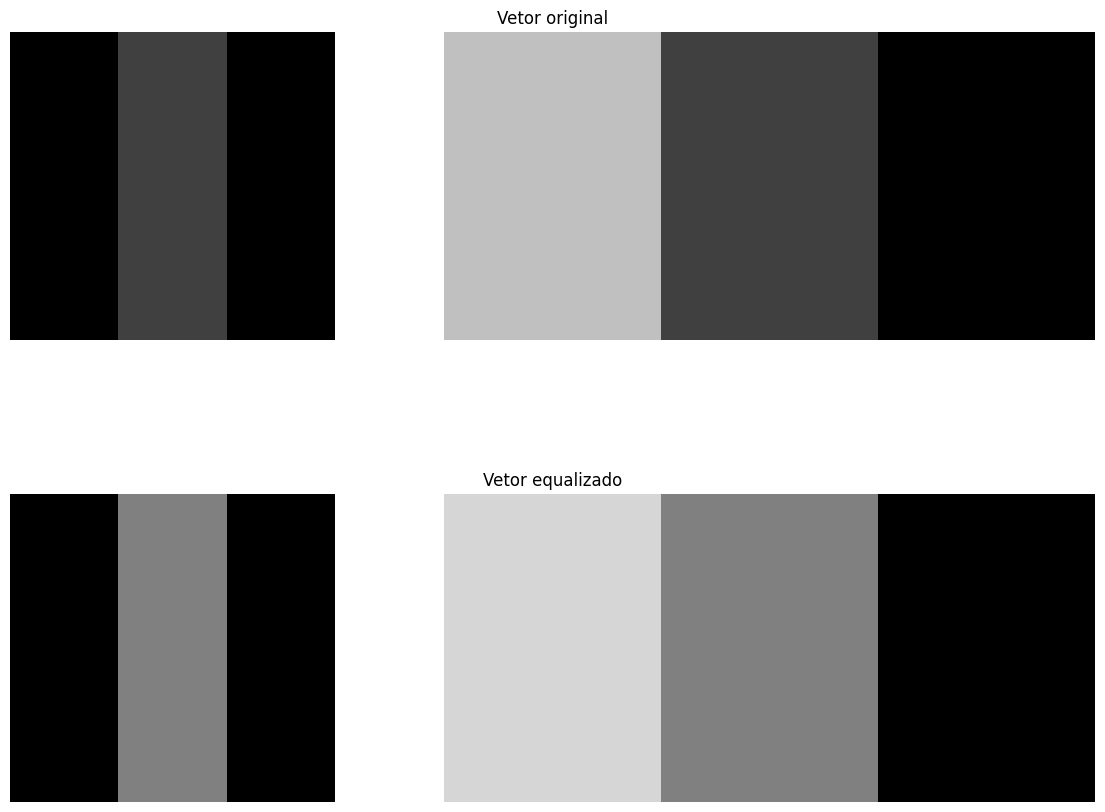

In [139]:
fig1, ax1 = gerar_imagem(
    contents,
    figsize=(14, 10),
    orient="vertical"
)
fig1.tight_layout()
fig1.savefig(PROJECT_DIR / "assets" / "atv04-q04.png", dpi=400)

# Questão 05

## Item a)

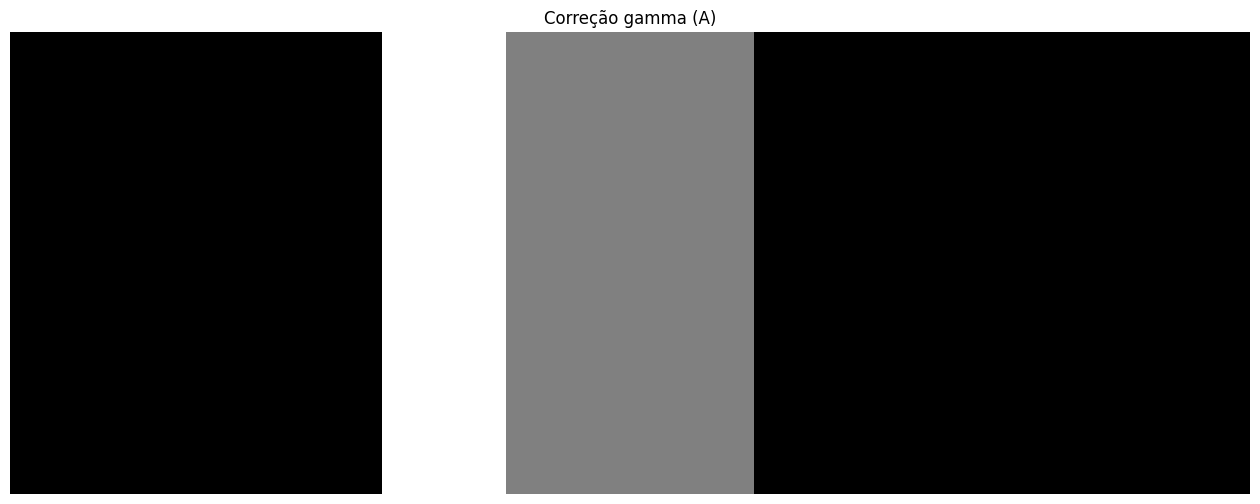

In [140]:
fig2, ax2 = gerar_imagem(
    {
        "gamma1": {
            "vetor": np.array([0, 0, 0, 2, 1, 1, 0, 0, 0, 0]),
            "desc": "Correção gamma (A)"
        }
    },
    figsize=(16, 6),
    orient="vertical"
)
fig2.tight_layout()
fig2.savefig(PROJECT_DIR / "assets" / "atv04-q05-01.png", dpi=400)

## Item b)

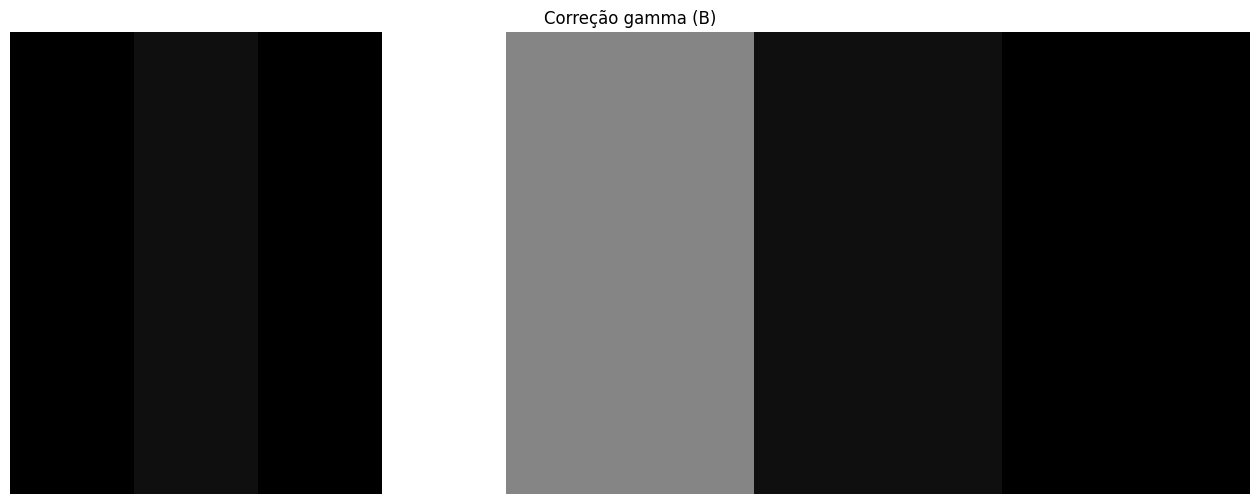

In [141]:
fig3, ax3 = gerar_imagem(
    {
        "gamma1": {
            "vetor": np.array([0, 3, 0, 50, 26, 26, 3, 3, 0, 0]),
            "desc": "Correção gamma (B)"
        }
    },
    figsize=(16, 6),
    orient="vertical"
)
fig3.tight_layout()
fig3.savefig(PROJECT_DIR / "assets" / "atv04-q05-02.png", dpi=400)

## Comparando resultados de ambos:

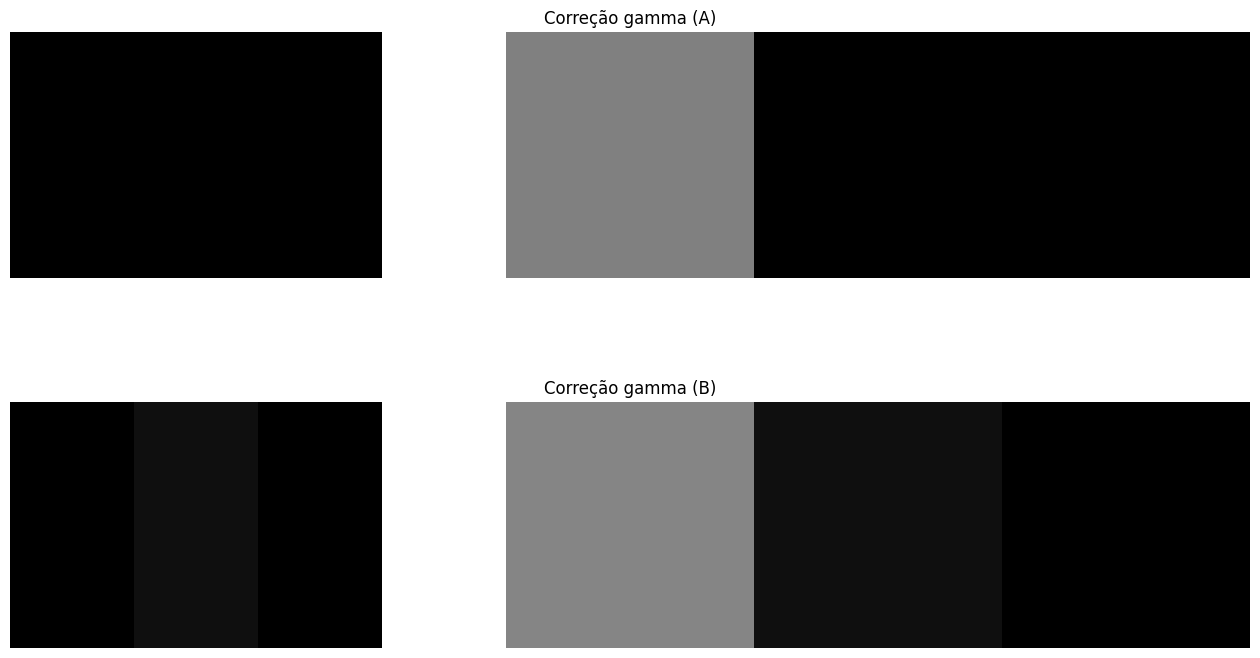

In [143]:
fig4, ax4 = gerar_imagem(
    {
        "gamma1": {
            "vetor": np.array([0, 0, 0, 2, 1, 1, 0, 0, 0, 0]),
            "desc": "Correção gamma (A)"
        },
        "gamma2": {
            "vetor": np.array([0, 3, 0, 50, 26, 26, 3, 3, 0, 0]),
            "desc": "Correção gamma (B)"
        }
    },
    figsize=(16, 8),
    orient="vertical"
)
fig4.tight_layout()
fig4.savefig(PROJECT_DIR / "assets" / "atv04-q05-03.png", dpi=400)

# Questão 06

In [144]:
R = np.array(
    [
        [255, 240, 200, 150, 120],
        [230, 220, 180, 160, 100],
        [210, 190, 170, 145, 90],
        [170, 160, 140, 130, 80],
        [185, 165, 155, 135, 122]
    ]
)

G = np.array(
    [
        [255, 240, 230, 235, 210],
        [240, 245, 250, 255, 180],
        [230, 220, 0, 230, 200],
        [240, 245, 250, 255, 180],
        [255, 240, 230, 235, 210]
    ]
)

B = np.array(
    [
        [255, 255, 200, 180, 160],
        [240, 230, 190, 140, 120],
        [245, 235, 0, 180, 160],
        [240, 230, 190, 140, 120],
        [255, 255, 200, 180, 160]
    ]
)

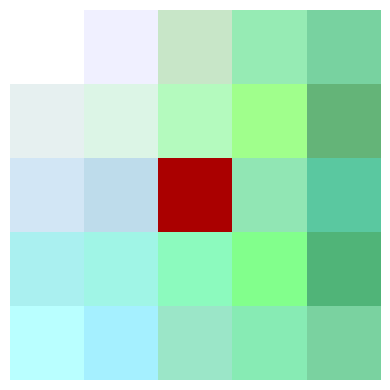

In [145]:
fig5, ax5 = gerar_imagem_rgb(R, G, B, figsize=(12, 4))
fig5.savefig(PROJECT_DIR / "assets" / "atv04-q06-01.png", dpi=400)

## Item A)

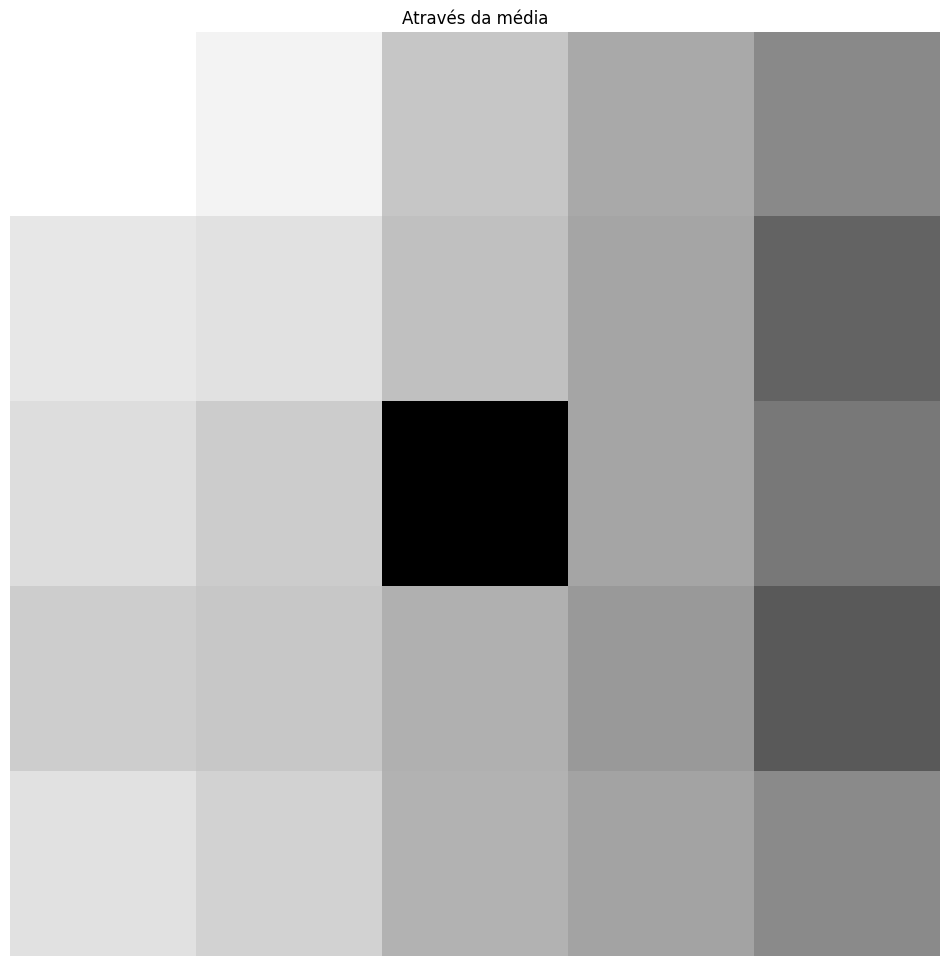

In [150]:
fig5, ax5 = gerar_imagem(
    {"media": {"desc": "Através da média", "vetor": (R + G + B) / 3}},
    figsize=(12, 12)
)
fig5.savefig(PROJECT_DIR / "assets" / "atv04-q06-02.png", dpi=400)

# Item B)

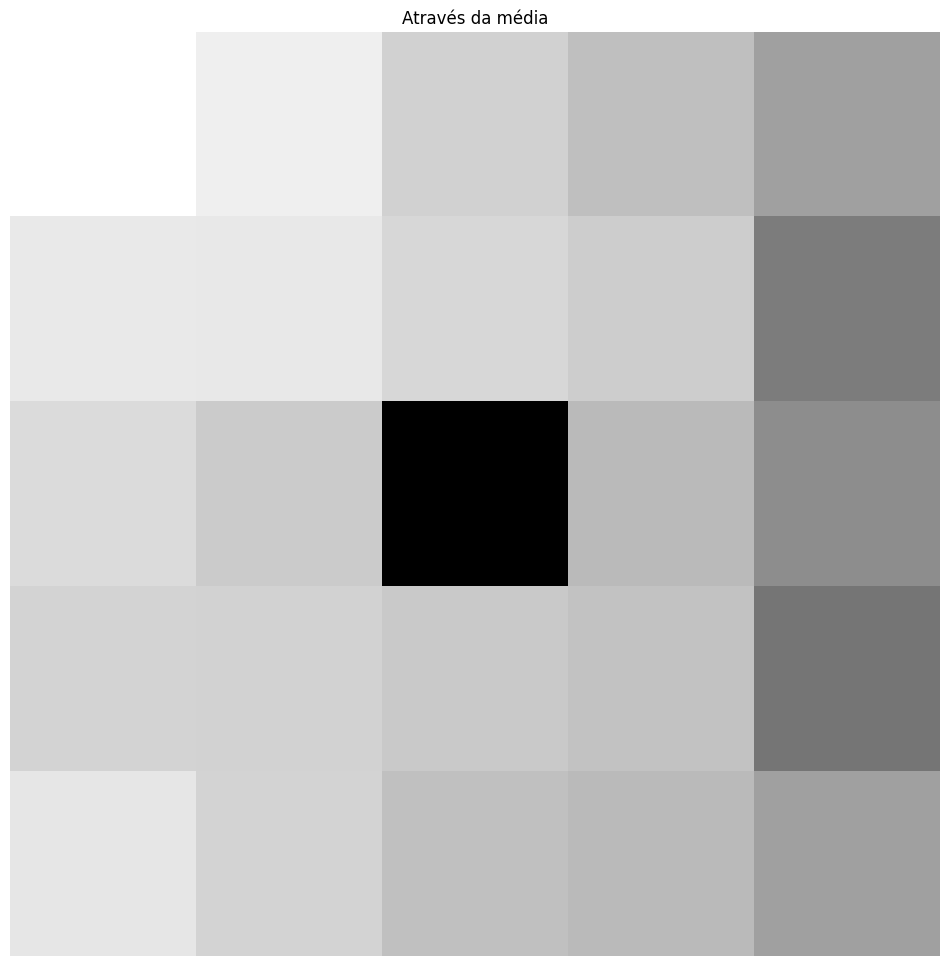

In [ ]:
fig6, ax6 = gerar_imagem(
    {"ponder": {"desc": "Ponderação", "vetor": (0.29 * R) + (0.59) * (G) + (0.11 * B)}},
    figsize=(12, 12)
)
fig6.savefig(PROJECT_DIR / "assets" / "atv04-q06-03.png", dpi=400)

# Item C)

In [ ]:
m = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        m[i, j] = (max(R[i, j], G[i, j], B[i, j]) + min(R[i, j], G[i, j], B[i, j])) / 2  # calculo de dessaturação

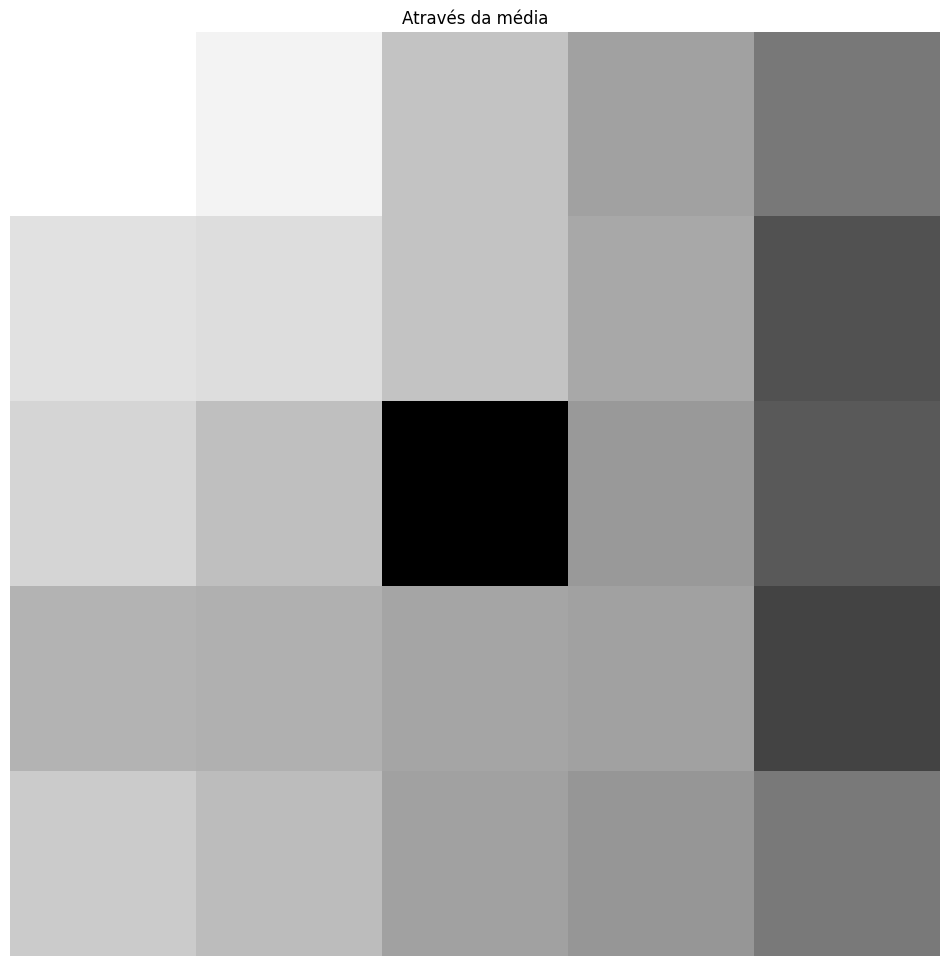

In [ ]:
fig7, ax7 = gerar_imagem(
    {"dess": {"desc": "Dessaturação", "vetor": m}},
    figsize=(12, 12)
)
fig7.savefig(PROJECT_DIR / "assets" / "atv04-q06-04.png", dpi=400)

## Imagens geradas

In [ ]:
fig8, ax7 = gerar_imagem(
    {
        "media": {"desc": "Através da média", "vetor": (R + G + B) / 3},
        "ponder": {"desc": "Através da média", "vetor": (0.29 * R) + (0.59) * (G) + (0.11 * B)},
        "dess": {"desc": "Dessaturação", "vetor": m}
    },
    figsize=(12, 12)
)
fig8.savefig(PROJECT_DIR / "assets" / "atv04-q06-05.png", dpi=400)